# 03. 도로타입 / 도로번호 / 지역 기반 돌발 패턴 분석

**주의**: 이 노트북의 `지역` 컬럼은 원본 전처리에 포함되어 있지 않아, 위경도(X, Y)와 17개 시/도 대표 좌표 간 최근접 거리로 근사 분류한 값입니다 (`src/region_mapping.py`). 실제 행정경계 기준 분류와 다를 수 있습니다.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import load
from src.plot_config import set_korean_style

set_korean_style()
FIG_DIR = pathlib.Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load()
df.shape

(623188, 19)

## 3.1 도로타입별 돌발 건수

/tmp/ipykernel_599/2396785597.py:6: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2396785597.py:6: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2396785597.py:6: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2396785597.py:6: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2396785597.py:6: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2396785597.py:6: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2396785597.py:6: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) Liberation Sa

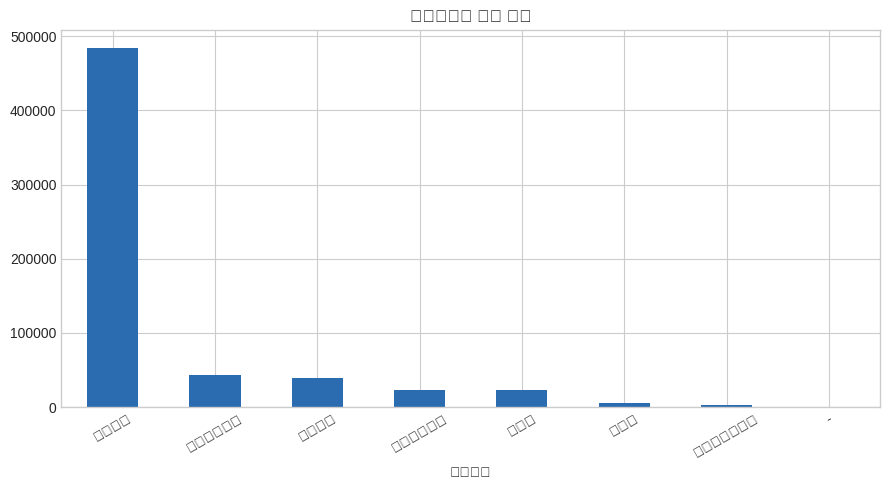

In [2]:
road_type_cnt = df['도로타입'].value_counts()
fig, ax = plt.subplots(figsize=(9,5))
road_type_cnt.plot(kind='bar', ax=ax, color='#2b6cb0')
ax.set_title('도로타입별 돌발 건수')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / '07_road_type_count.png', dpi=150)
plt.show()

## 3.2 도로타입별 돌발구분 구성비

돌발구분,공사,교통사고,기상,기타,기타돌발,재난
도로타입,,,,,,
-,61.28,29.77,0.93,8.02,0.00,0.00
고속국도,25.22,19.98,7.53,1.18,43.42,2.67
국가지원지방도,62.25,29.72,0.59,7.44,0.00,0.00
도시고속국도,22.72,75.99,0.58,0.70,0.00,0.00
시군도,76.41,17.70,1.22,4.67,0.00,0.00
일반국도,63.85,25.84,0.78,2.84,6.44,0.25
지방도,75.11,19.80,3.51,1.58,0.00,0.00
특별광역시도,56.01,34.45,0.74,8.79,0.00,0.00


/tmp/ipykernel_599/2091625268.py:11: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2091625268.py:11: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2091625268.py:11: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2091625268.py:11: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2091625268.py:11: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2091625268.py:11: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/2091625268.py:11: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Liberation S

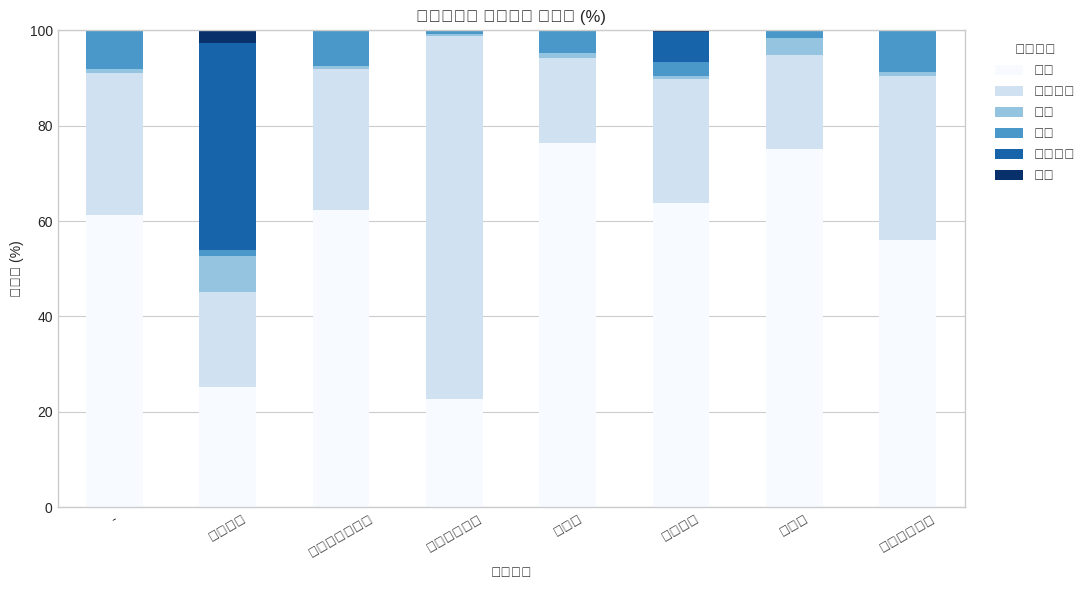

In [3]:
comp = pd.crosstab(df['도로타입'], df['돌발구분'], normalize='index') * 100
comp = comp.round(2)
display(comp)

fig, ax = plt.subplots(figsize=(11,6))
comp.plot(kind='bar', stacked=True, ax=ax, colormap='Blues')
ax.set_title('도로타입별 돌발구분 구성비 (%)')
ax.set_ylabel('구성비 (%)')
plt.xticks(rotation=30)
ax.legend(title='돌발구분', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_road_type_composition.png', dpi=150)
plt.show()

## 3.3 도로번호별 돌발 비율 (Top, 2% 이상만 표시)

/tmp/ipykernel_599/3827125826.py:10: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/3827125826.py:10: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/3827125826.py:10: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/3827125826.py:10: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/3827125826.py:10: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/3827125826.py:10: UserWarning: Glyph 46028 (\N{HANGUL SYLLABLE DOL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/3827125826.py:10: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from font(s) Liberatio

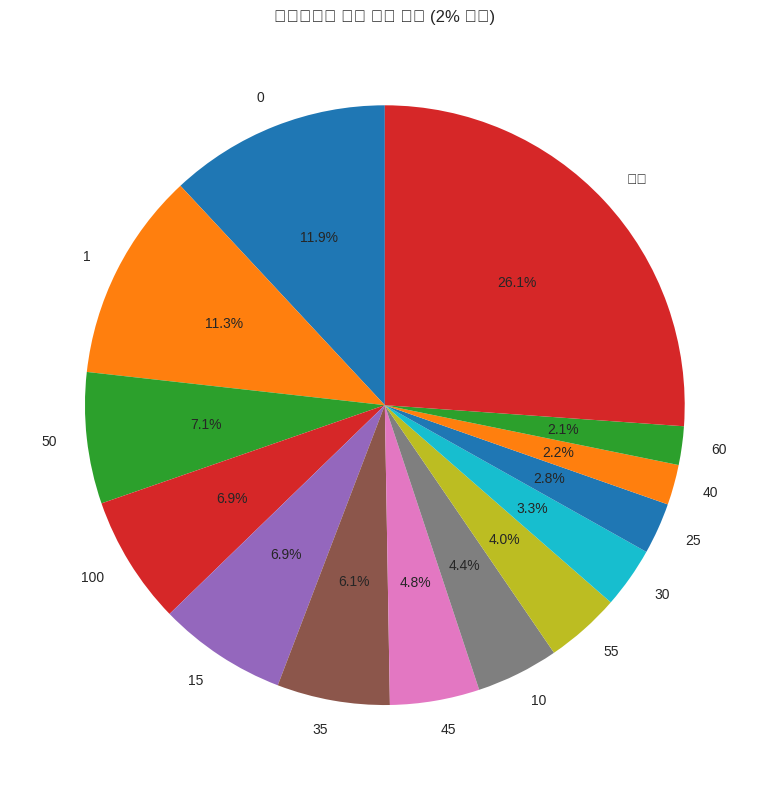

In [4]:
road_num = df['도로번호'].dropna().astype(int).astype(str)
pct = road_num.value_counts(normalize=True) * 100
top_roads = pct[pct >= 2]
etc = pd.Series({'기타': pct[pct < 2].sum()})
pie_data = pd.concat([top_roads, etc])

fig, ax = plt.subplots(figsize=(8,8))
ax.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
ax.set_title('도로번호별 돌발 발생 비율 (2% 이상)')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_road_number_pie.png', dpi=150)
plt.show()

## 3.4 시/도별 돌발 횟수 (근사 지역 분류)

/tmp/ipykernel_599/581957885.py:9: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/581957885.py:9: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/581957885.py:9: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/581957885.py:9: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/581957885.py:9: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/581957885.py:9: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_599/581957885.py:9: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) Liberation Sans.
  plt

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


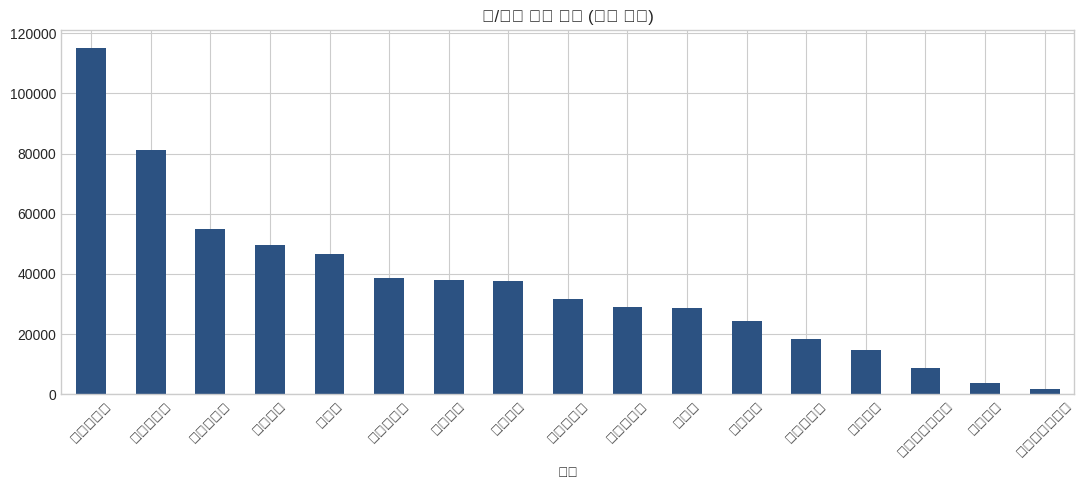

In [5]:
from src.region_mapping import assign_region
df['지역'] = assign_region(df['Y'], df['X'])

region_cnt = df['지역'].value_counts()
fig, ax = plt.subplots(figsize=(11,5))
region_cnt.plot(kind='bar', ax=ax, color='#2c5282')
ax.set_title('시/도별 돌발 건수 (근사 분류)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / '10_region_count.png', dpi=150)
plt.show()

## 3.5 시/도별 Top1 돌발유형

In [6]:
region_type = pd.crosstab(df['지역'], df['돌발구분'], normalize='index') * 100
region_top1 = region_type.idxmax(axis=1)
pd.DataFrame({'Top1 돌발구분': region_top1}).sort_index()

,Top1 돌발구분
지역,
강원도,기타돌발
경기도,기타돌발
경상남도,기타돌발
경상북도,공사
광주광역시,공사
대구광역시,기타돌발
대전광역시,공사
부산광역시,공사
서울특별시,교통사고
